In [21]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [22]:
# Load Datasets
df_normal = pd.read_csv('/content/drive/MyDrive/python-ml-lab/exp9_10/data/ptbdb_normal.csv', header=None)
df_abnormal = pd.read_csv('/content/drive/MyDrive/python-ml-lab/exp9_10/data/ptbdb_abnormal.csv', header=None)
df_normal.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,1.000000,0.900324,0.358590,0.051459,0.046596,0.126823,0.133306,0.119125,0.110616,0.113047,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.000000,0.794681,0.375387,0.116883,0.000000,0.171923,0.283859,0.293754,0.325912,0.345083,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.909029,0.791482,0.423169,0.186712,0.000000,0.007836,0.063032,0.077002,0.074957,0.077342,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.000000,0.478893,0.056760,0.064176,0.081289,0.072732,0.055619,0.048774,0.054478,0.041643,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.000000,0.867238,0.201360,0.099349,0.141336,0.120934,0.108516,0.096393,0.093436,0.100828,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [41]:
# Add labels
df_normal['label'] = 0
df_abnormal['label'] = 1

# Combine and shuffle
df = pd.concat([df_normal, df_abnormal], axis=0)
df = df.dropna().sample(frac=1, random_state=42).reset_index(drop=True)

# Split features and target
X = df.iloc[:, :187].values
y = df.iloc[:, -1].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
# Combine and shuffle
df = pd.concat([df_normal, df_abnormal], axis=0)
df = df.dropna().sample(frac=1, random_state=42).reset_index(drop=True)

In [25]:
# Split features and target
X = df.iloc[:, :187].values
y = df.iloc[:, -1].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [26]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
# Logistic Regression
LR = LogisticRegression(max_iter=1000)
LR.fit(X_train_scaled, y_train)

# Random Forest
RF = RandomForestClassifier(n_estimators=100, random_state=42)
RF.fit(X_train_scaled, y_train)

# XGBoost
XGB = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
XGB.fit(X_train_scaled, y_train)

# K-Nearest Neighbors (KNN)
KNN = KNeighborsClassifier(n_neighbors=5)
KNN.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:23:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


KNeighborsClassifier()

In [27]:
# --- Accuracy Scores ---

lr_acc = accuracy_score(y_test, LR.predict(X_test_scaled))
rf_acc = accuracy_score(y_test, RF.predict(X_test_scaled))
xgb_acc = accuracy_score(y_test, XGB.predict(X_test_scaled))
knn_acc = accuracy_score(y_test, KNN.predict(X_test_scaled))

print("Logistic Regression Accuracy:", lr_acc)
print("Random Forest Accuracy:", rf_acc)
print("XGBoost Accuracy:", xgb_acc)
print("KNN Accuracy:", knn_acc)

Logistic Regression Accuracy: 0.8169014084507042
Random Forest Accuracy: 0.9708004122294744
XGBoost Accuracy: 0.9759532806595672
KNN Accuracy: 0.9168670559945036


In [28]:
# --- Precision Scores ---

lr_precision = precision_score(y_test, LR.predict(X_test_scaled), average='weighted')
rf_precision = precision_score(y_test, RF.predict(X_test_scaled), average='weighted')
xgb_precision = precision_score(y_test, XGB.predict(X_test_scaled), average='weighted')
knn_precision = precision_score(y_test, KNN.predict(X_test_scaled), average='weighted')

print("LR Precision:", lr_precision)
print("RF Precision:", rf_precision)
print("XGB Precision:", xgb_precision)
print("KNN Precision:", knn_precision)

LR Precision: 0.8105699997303598
RF Precision: 0.970767745413276
XGB Precision: 0.9758832348894024
KNN Precision: 0.9179222182896357


In [29]:
# --- Recall Scores ---

lr_recall = recall_score(y_test, LR.predict(X_test_scaled), average='weighted')
rf_recall = recall_score(y_test, RF.predict(X_test_scaled), average='weighted')
xgb_recall = recall_score(y_test, XGB.predict(X_test_scaled), average='weighted')
knn_recall = recall_score(y_test, KNN.predict(X_test_scaled), average='weighted')

print("LR Recall:", lr_recall)
print("RF Recall:", rf_recall)
print("XGB Recall:", xgb_recall)
print("KNN Recall:", knn_recall)

LR Recall: 0.8169014084507042
RF Recall: 0.9708004122294744
XGB Recall: 0.9759532806595672
KNN Recall: 0.9168670559945036


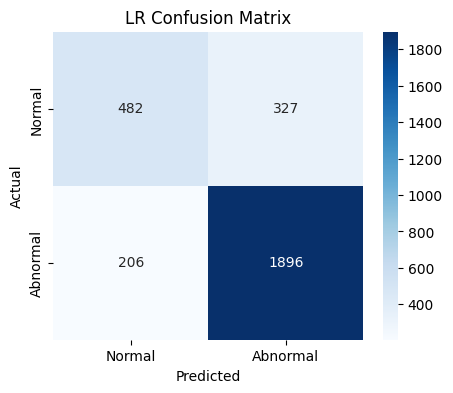

In [30]:
# Logistic Regression Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, LR.predict(X_test_scaled)), annot=True, fmt='d', cmap='Blues',xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
plt.title("LR Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

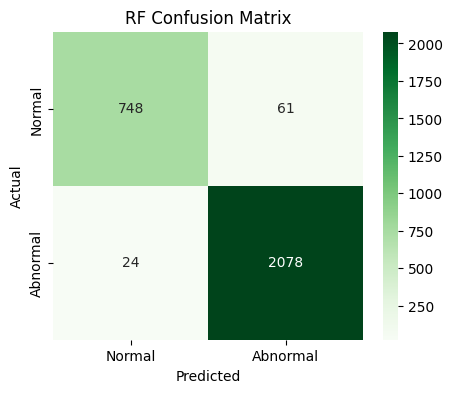

In [36]:
# Random Forest Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, RF.predict(X_test_scaled)), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
plt.title("RF Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

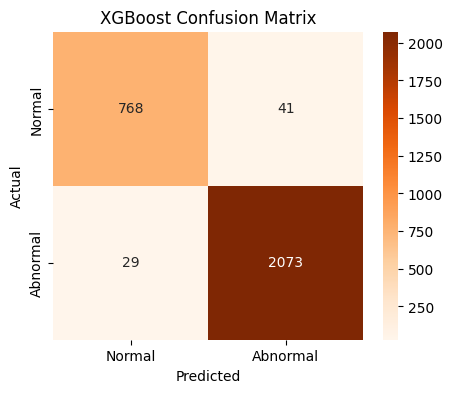

In [37]:
# XGBoost Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, XGB.predict(X_test_scaled)), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

/tmp/ipykernel_1862/819542607.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


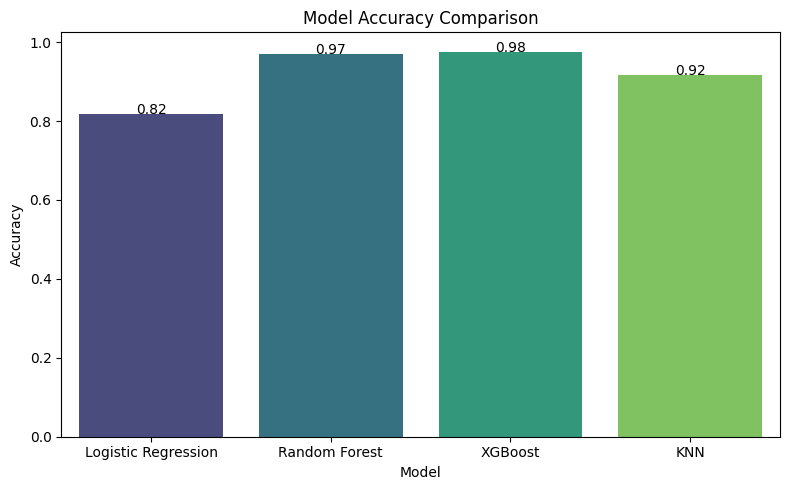

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the results dictionary
results = {
    'Logistic Regression': lr_acc,
    'Random Forest': rf_acc,
    'XGBoost': xgb_acc,
    'KNN': knn_acc
}

# Visualization
plt.figure(figsize=(8, 5))

sns.barplot(
    x=list(results.keys()),
    y=list(results.values()),
    palette='viridis'
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

# Add values on bars
for i, v in enumerate(results.values()):
    plt.text(i, v, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.show()

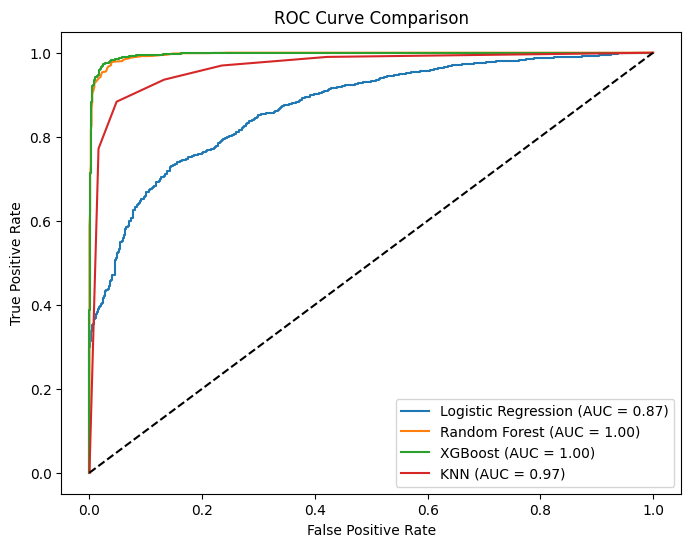

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Define models_dict
models_dict = {
    'Logistic Regression': LR,
    'Random Forest': RF,
    'XGBoost': XGB,
    'KNN': KNN
}

plt.figure(figsize=(8, 6))

# Loop through all models
for name, model in models_dict.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Random line
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [40]:
import pickle
import os
# Create folder if not exists
if not os.path.exists("models"):
  os.makedirs("models")
# Save models
for name, model in models_dict.items():
  file_name = "models/" + name + ".pkl"
  with open(file_name, "wb") as f:
    pickle.dump(model, f)
    print(name, "model saved")

# Save the scaler
with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
    print("StandardScaler saved")

Logistic Regression model saved
Random Forest model saved
XGBoost model saved
KNN model saved
StandardScaler saved
